# 01 — Exploración del Corpus Legal

Análisis del corpus `final_json/`: estadísticas, distribución de categorías, longitud de textos y calidad de los datos.

In [5]:
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Cargar todos los documentos
registros = []
for path in glob.glob('../final_json/**/*.json', recursive=True):
    with open(path, encoding='utf-8') as f:
        entradas = json.load(f)
    for d in entradas:
        d['archivo'] = path
        registros.append(d)

df = pd.DataFrame(registros)
print(f'Total de entradas: {len(df)}')
df.head(3)

Total de entradas: 1349


,id,nombre_doc,tipo_doc,capitulo_seccion,categoria_consumo,texto,source,archivo
0,1,Anexos de la Resolución SBS N° 3274-2017,informe,ANEXO Nº 3 EJEMPLOS DE CARGOS QUE NO SE ADECUA...,[servicios financieros y seguros],"Los cargos que se indican a continuación, a ma...",0001_los_cargos_que_se_indican_a_continuación_...,../final_json\informes\Anexos de la Resolución...
1,2,Anexos de la Resolución SBS N° 3274-2017,informe,ANEXO Nº 3 EJEMPLOS DE CARGOS QUE NO SE ADECUA...,[servicios financieros y seguros],9. Cargos por consultas realizadas a centrale...,0002_9_cargos_por_consultas_realizadas_a_centr...,../final_json\informes\Anexos de la Resolución...
2,3,Anexos de la Resolución SBS N° 3274-2017,informe,ANEXO Nº 3 EJEMPLOS DE CARGOS QUE NO SE ADECUA...,[servicios financieros y seguros],18. Cargos en cuentas pasivas cuando su apertu...,0003_18_cargos_en_cuentas_pasivas_cuando_su_ap...,../final_json\informes\Anexos de la Resolución...


In [6]:
# Distribución por tipo de documento
print('Distribución por tipo_doc:')
print(df['tipo_doc'].value_counts())
print()
print('Archivos por tipo:')
print(df.groupby('tipo_doc')['nombre_doc'].nunique())

Distribución por tipo_doc:
tipo_doc
informe                632
norma reglamentaria    477
ley                    240
Name: count, dtype: int64

Archivos por tipo:
tipo_doc
informe                13
ley                     5
norma reglamentaria    10
Name: nombre_doc, dtype: int64


In [7]:
# Distribución de categorías de consumo
todas_cats = []
for cats in df['categoria_consumo']:
    todas_cats.extend(cats)

conteo_cats = Counter(todas_cats)
print('Top categorías de consumo:')
for cat, n in conteo_cats.most_common():
    print(f'  {n:>4}  {cat}')

Top categorías de consumo:
   454  servicios financieros y seguros
   316  consumo en general
   158  telecomunicaciones
    94  agua y alcantarillado
    62  inmuebles
    58  productos y servicios
    56  luz y servicio eléctrico
    56  gas y combustibles
    54  transporte
    41  entidades públicas
    32  educación
    22  salud


Estadísticas de longitud (palabras por entrada):
count    1349.0
mean      158.8
std       129.4
min         2.0
25%        73.0
50%       129.0
75%       205.0
max       995.0
Name: num_palabras, dtype: float64


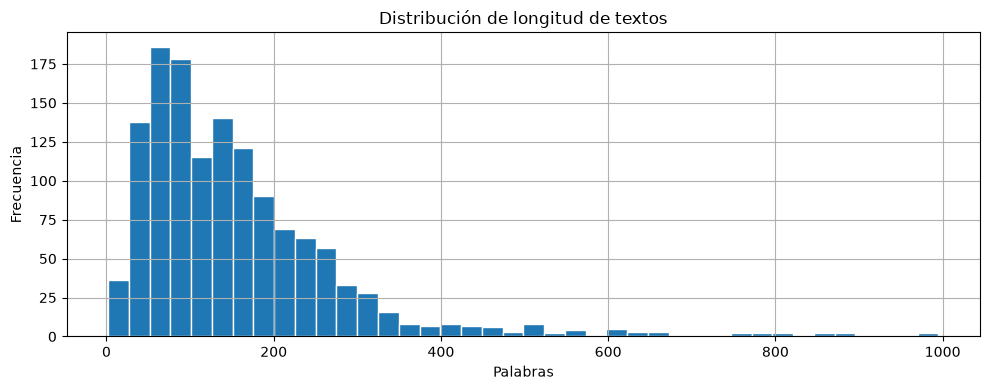

In [8]:
# Longitud de textos (en palabras)
df['num_palabras'] = df['texto'].str.split().str.len()

print('Estadísticas de longitud (palabras por entrada):')
print(df['num_palabras'].describe().round(1))

fig, ax = plt.subplots(figsize=(10, 4))
df['num_palabras'].hist(bins=40, ax=ax, edgecolor='white')
ax.set_title('Distribución de longitud de textos')
ax.set_xlabel('Palabras')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [9]:
# Textos más largos (posibles candidatos a chunking)
umbral_tokens = 400  # ~512 tokens aproximado
largos = df[df['num_palabras'] > umbral_tokens]
print(f'Entradas con más de {umbral_tokens} palabras: {len(largos)}')
if len(largos) > 0:
    print('\nDocumentos afectados:')
    print(largos[['nombre_doc', 'num_palabras']].to_string(index=False))

Entradas con más de 400 palabras: 64

Documentos afectados:
                                                            nombre_doc  num_palabras
Guía de reclamos y quejas en el servicio público de telecomunicaciones           460
Guía de reclamos y quejas en el servicio público de telecomunicaciones           431
        Lineamientos sobre Protección al Consumidor - Actualizado 2022           451
                         Código de Protección y Defensa del Consumidor           571
                         Código de Protección y Defensa del Consumidor           440
                         Código de Protección y Defensa del Consumidor           768
                         Código de Protección y Defensa del Consumidor           576
                         Código de Protección y Defensa del Consumidor           620
                         Código de Protección y Defensa del Consumidor           503
                         Código de Protección y Defensa del Consumidor           493
     

In [12]:
# Muestra de texto: comparar fuente legal vs. lo que verá el LLM
muestra = df[df['tipo_doc'] == 'ley'].iloc[0]
print(f'Documento: {muestra["nombre_doc"]}')
print(f'Sección:   {muestra["capitulo_seccion"]}')
print(f'Palabras:  {muestra["num_palabras"]}')
print()
print('--- TEXTO LEGAL ---')
print(muestra['texto'])

Documento: Código de Protección y Defensa del Consumidor
Sección:   TÍTULO PRELIMINAR
Palabras:  75

--- TEXTO LEGAL ---
Artículo I.- Contenido
El presente Código establece las normas de protección y defensa de los consumidores, instituyendo como un principio rector de la política social y económica del Estado la protección de los derechos de los consumidores, dentro del marco del artículo 65 de la Constitución Política del Perú y en un régimen de economía social de mercado, establecido en el Capítulo I del Título III, Del Régimen Económico, de la Constitución Política del Perú.
